In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import random
import tensorflow.keras.backend as K
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.metrics import Precision, Recall
from sklearn.metrics import f1_score, jaccard_score, accuracy_score, precision_score, recall_score
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
images_dir = 'data/images/'
labels_dir = 'data/labels/'

IMG_HEIGHT = 128
IMG_WIDTH = 128
NUM_BANDS = 12  

In [ ]:
def load_images_and_masks(images_dir, labels_dir, normalization='min-max'):
    images, masks = [], []

    for file_name in os.listdir(images_dir):
        if file_name.endswith('.tif'):
            img_path = os.path.join(images_dir, file_name)
            mask_path = os.path.join(labels_dir, file_name.replace('.tif', '.png'))

            if not os.path.exists(mask_path):
                continue

            with rasterio.open(img_path) as src:
                image = src.read()
                image = np.transpose(image, (1, 2, 0))

            mask = plt.imread(mask_path)
            mask = (mask > 0).astype(np.uint8)  

            if normalization == 'min-max':
                image = (image - np.min(image)) / (np.max(image) - np.min(image) + 1e-8)
            elif normalization == 'z-score':
                image = (image - np.mean(image)) / (np.std(image) + 1e-8)

            images.append(image)
            masks.append(mask)

    return np.array(images), np.array(masks)

In [4]:
images, masks = load_images_and_masks(images_dir, labels_dir, normalization='min-max')

c:\Users\Dodooz\AppData\Local\Programs\Python\Python38\lib\site-packages\rasterio\__init__.py:333: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(images, masks, test_size=0.2, random_state=42)

In [6]:
# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2
)
train_generator = datagen.flow(X_train, y_train, batch_size=8)

c:\Users\Dodooz\AppData\Local\Programs\Python\Python38\lib\site-packages\keras\src\preprocessing\image.py:766: UserWarning: NumpyArrayIterator is set to use the data format convention "channels_last" (channels on axis 3), i.e. expected either 1, 3, or 4 channels on axis 3. However, it was passed an array with shape (244, 128, 128, 12) (12 channels).
  warnings.warn(


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers, losses
from tensorflow.keras.metrics import Precision, Recall

def build_pretrained_unet(input_shape):
    inputs = layers.Input(shape=input_shape)

    
    reshaped_inputs = layers.Conv2D(3, (1, 1), activation='relu', padding='same')(inputs)

   
    base_model = ResNet50(weights=None, include_top=False, input_tensor=reshaped_inputs)

    
    skip_connections = [
        base_model.get_layer("conv1_conv").output,  
        base_model.get_layer("conv2_block3_out").output,  
        base_model.get_layer("conv3_block4_out").output,  
        base_model.get_layer("conv4_block6_out").output   
    ]

    x = base_model.output  

   
    b1 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    b1 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(b1)

    u1 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(b1)
    u1 = layers.concatenate([u1, skip_connections[3]])
    c1 = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(u1)

    u2 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c1)
    u2 = layers.concatenate([u2, skip_connections[2]])
    c2 = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(u2)

    u3 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c2)
    u3 = layers.concatenate([u3, skip_connections[1]])
    c3 = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(u3)

    u4 = layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c3)
    u4 = layers.concatenate([u4, skip_connections[0]])
    c4 = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(u4)

    u5 = layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c4)
    c5 = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(u5)

    outputs = layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same')(c5)

    model = models.Model(inputs=[inputs], outputs=[outputs])
    return model


IMG_HEIGHT, IMG_WIDTH, NUM_BANDS = 128, 128, 12
input_shape = (IMG_HEIGHT, IMG_WIDTH, NUM_BANDS)


model = build_pretrained_unet(input_shape)

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss=losses.BinaryCrossentropy(),
              metrics=[Precision(name='precision'), Recall(name='recall')])

In [8]:
history = model.fit(X_train, y_train, epochs=200, batch_size=8, validation_split=0.2)

Epoch 1/200
25/25 [==============================] - 65s 2s/step - loss: 0.5835 - precision: 0.4265 - recall: 0.0497 - val_loss: 0.6545 - val_precision: 0.2174 - val_recall: 2.1460e-05
Epoch 2/200
25/25 [==============================] - 35s 1s/step - loss: 0.4871 - precision: 0.7437 - recall: 0.2600 - val_loss: 0.6455 - val_precision: 0.9931 - val_recall: 0.1254
Epoch 3/200
25/25 [==============================] - 34s 1s/step - loss: 0.4292 - precision: 0.8382 - recall: 0.4975 - val_loss: 0.5496 - val_precision: 0.9984 - val_recall: 0.2287
Epoch 4/200
25/25 [==============================] - 36s 1s/step - loss: 0.3961 - precision: 0.8601 - recall: 0.5366 - val_loss: 0.5001 - val_precision: 0.9819 - val_recall: 0.3686
Epoch 5/200
25/25 [==============================] - 38s 2s/step - loss: 0.3602 - precision: 0.8892 - recall: 0.5846 - val_loss: 0.4575 - val_precision: 0.9779 - val_recall: 0.4628
Epoch 6/200
25/25 [==============================] - 34s 1s/step - loss: 0.3283 - precision

In [9]:
model.save('pretrained_unet_model.h5')

c:\Users\Dodooz\AppData\Local\Programs\Python\Python38\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [ ]:
import tensorflow.keras.backend as K

def dice_loss(y_true, y_pred):
    smooth = 1e-6
    y_true_f = K.flatten(y_true)  
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return 1 - (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)


In [ ]:

pretrained_model = tf.keras.models.load_model('pretrained_unet_model.h5', custom_objects={'dice_loss': dice_loss})


y_pred = pretrained_model.predict(X_test)
y_pred_binary = (y_pred > 0.5).astype(np.uint8)


y_test_binary = y_test.astype(np.uint8)
y_test_flat = y_test_binary.flatten()
y_pred_flat = y_pred_binary.flatten()

precision = precision_score(y_test_flat, y_pred_flat, zero_division=1)
recall = recall_score(y_test_flat, y_pred_flat, zero_division=1)
f1 = f1_score(y_test_flat, y_pred_flat, zero_division=1)
iou = jaccard_score(y_test_flat, y_pred_flat)
accuracy = accuracy_score(y_test_flat, y_pred_flat)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"IoU: {iou:.4f}")
print(f"Accuracy: {accuracy:.4f}")

2/2 [==============================] - 2s 618ms/step
Precision: 0.9178
Recall: 0.8799
F1 Score: 0.8984
IoU: 0.8156
Accuracy: 0.9554


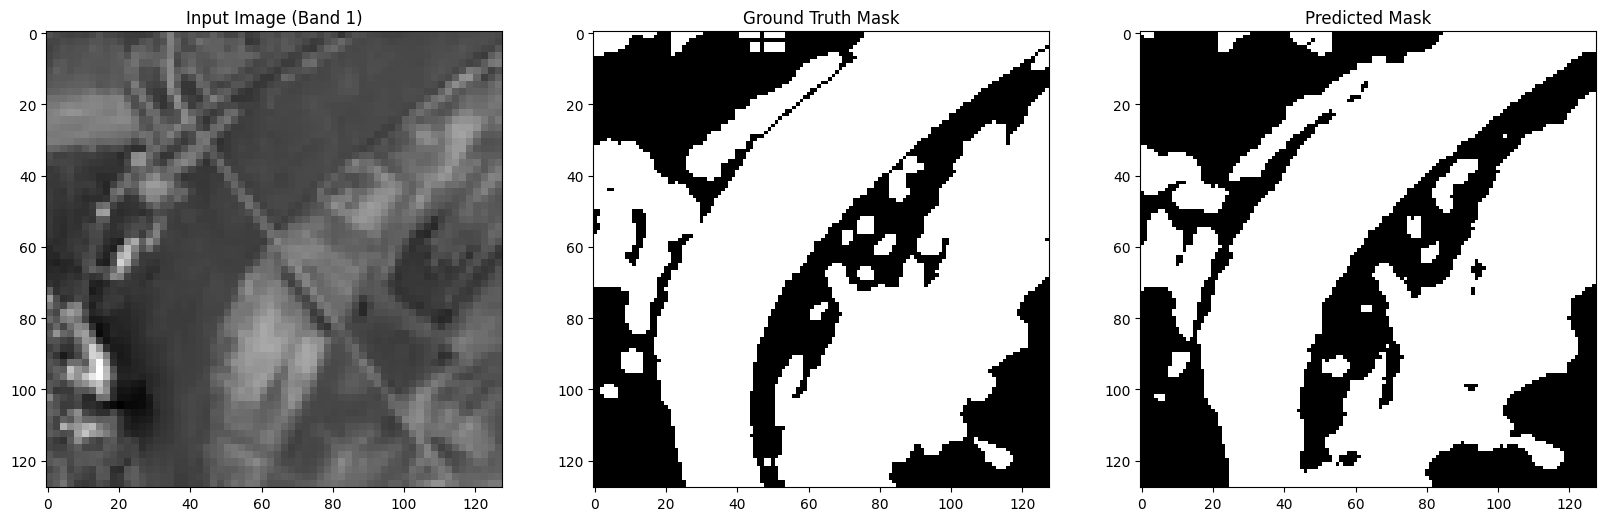

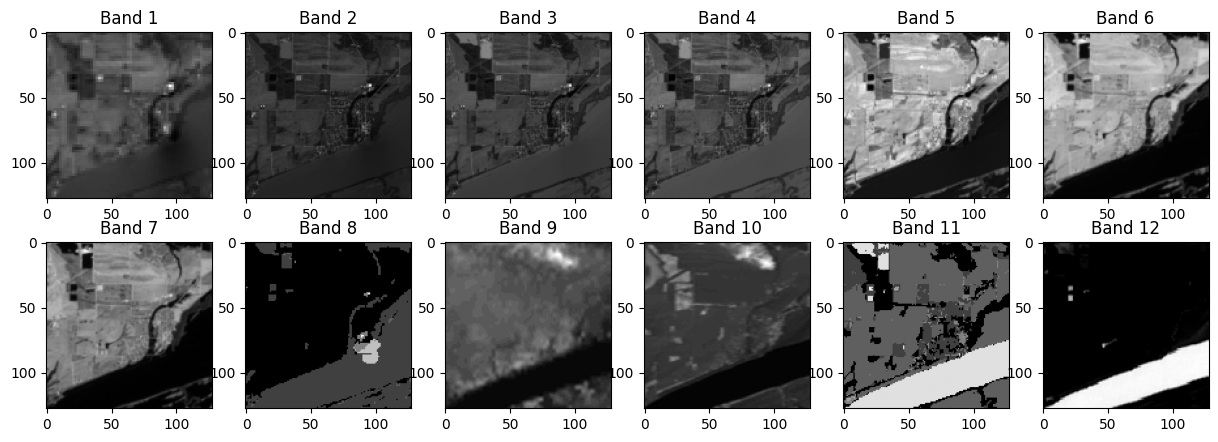

In [12]:
def visualize_bands(image, num_bands=12):
    plt.figure(figsize=(15, 5))
    for i in range(min(num_bands, image.shape[2])):
        plt.subplot(2, 6, i+1)
        plt.imshow(image[:, :, i], cmap='gray')
        plt.title(f'Band {i+1}')
    plt.show()

def visualize_random_prediction(X_test, y_test, y_pred_binary):
    idx = random.randint(0, len(X_test) - 1)
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 3, 1)
    plt.imshow(X_test[idx][:, :, 0], cmap='gray')
    plt.title('Input Image (Band 1)')
    plt.subplot(1, 3, 2)
    plt.imshow(y_test[idx], cmap='gray')
    plt.title('Ground Truth Mask')
    plt.subplot(1, 3, 3)
    plt.imshow(y_pred_binary[idx], cmap='gray')
    plt.title('Predicted Mask')
    plt.show()

visualize_random_prediction(X_test, y_test, y_pred_binary)
visualize_bands(X_test[random.randint(0, len(X_test) - 1)])
